# COMM074 – Practical Business Analytics
## Group Notebook: Section 5 – Model Evaluation & Visualisation Dashboard

**Group Members:** Akash Chohan, Parth, Piyush, Nagashri
**Dataset:** IBM Transactions for Anti-Money Laundering (AML) – HI-Small
**Source:** https://www.kaggle.com/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml

### Overview
This final master notebook covers the Evaluation phase of the CRISP-DM lifecycle. It aggregates the performance metrics of all eight unique machine learning models developed individually by the group members during Section 3.

The purpose of this notebook is to generate a comprehensive, senior management-ready visual dashboard. By comparing Linear Models (Logistic Regression variants), Tree-Based Ensembles (Random Forest, XGBoost, LightGBM), and Neural Networks (MLP) across key metrics (Recall, Precision, ROC-AUC, and AUPRC), this notebook provides the empirical justification for the final business recommendations outlined in Section 5 of the group report.

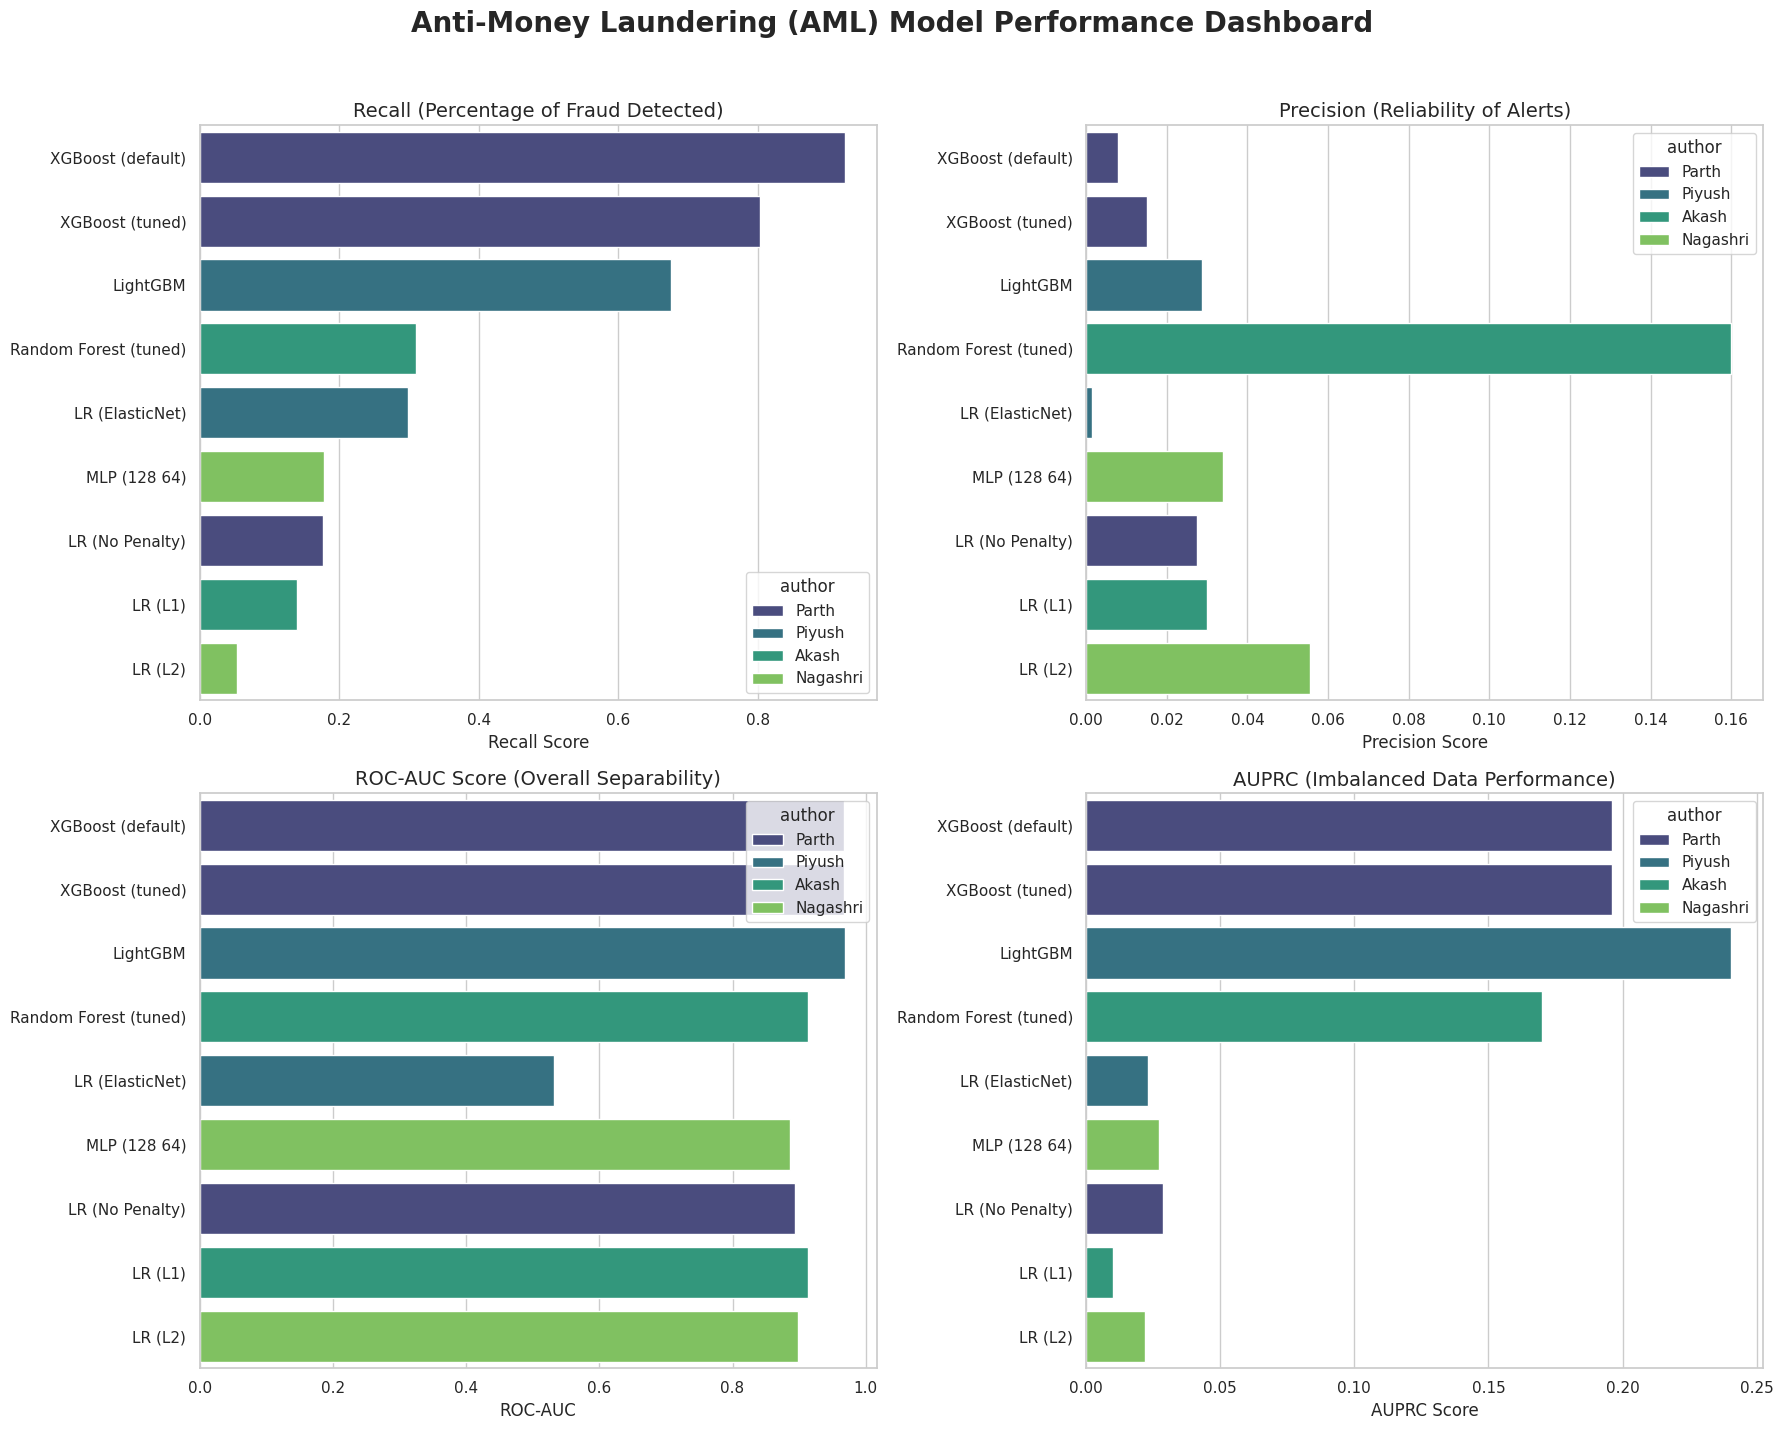

In [1]:
# ==========================================
# SECTION 5: GROUP VISUALISATION DASHBOARD
# Comparing all 8 models developed by the group
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load the cross-group comparison CSV
df_results = pd.read_csv('/content/drive/MyDrive/COM074_Group_Project/cross_group_comparison_final.csv')

# 2. Sort by Recall (Our most important business metric)
df_sorted = df_results.sort_values(by='recall', ascending=False)

# 3. Create a Senior Management Dashboard (2x2 Grid)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Anti-Money Laundering (AML) Model Performance Dashboard', fontsize=20, fontweight='bold', y=1.02)

# Panel 1: Recall Comparison (Fraud Caught)
sns.barplot(data=df_sorted, x='recall', y='model', ax=axes[0,0], hue='author', dodge=False, palette='viridis')
axes[0,0].set_title('Recall (Percentage of Fraud Detected)', fontsize=14)
axes[0,0].set_xlabel('Recall Score')
axes[0,0].set_ylabel('')

# Panel 2: Precision Comparison (False Alarm Rate Indicator)
sns.barplot(data=df_sorted, x='precision', y='model', ax=axes[0,1], hue='author', dodge=False, palette='viridis')
axes[0,1].set_title('Precision (Reliability of Alerts)', fontsize=14)
axes[0,1].set_xlabel('Precision Score')
axes[0,1].set_ylabel('')

# Panel 3: ROC-AUC Comparison
sns.barplot(data=df_sorted, x='roc_auc', y='model', ax=axes[1,0], hue='author', dodge=False, palette='viridis')
axes[1,0].set_title('ROC-AUC Score (Overall Separability)', fontsize=14)
axes[1,0].set_xlabel('ROC-AUC')
axes[1,0].set_ylabel('')

# Panel 4: AUPRC Comparison (Area Under Precision-Recall Curve)
sns.barplot(data=df_sorted, x='auprc', y='model', ax=axes[1,1], hue='author', dodge=False, palette='viridis')
axes[1,1].set_title('AUPRC (Imbalanced Data Performance)', fontsize=14)
axes[1,1].set_xlabel('AUPRC Score')
axes[1,1].set_ylabel('')

plt.tight_layout()
plt.show()